# הגשה - מטלת חיזוי

**שם:** ALI HAMED  
**תעודת זהות:** 325274520


# Process-Mining-Lab: Prediction

### Imports & Data-Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Read the event log
df = pd.read_csv("patients-log.csv")

# Clean column names
df.columns = df.columns.str.strip()

# Convert DateTime column to datetime type
df["DateTime"] = pd.to_datetime(df["DateTime"])

# Show basic info
df.head()

,patient,action,org:resource,DateTime
0,patient 0,First consult,Dr. Anna,2017-01-02 11:40:11
1,patient 0,Blood test,Lab,2017-01-02 12:47:33
2,patient 0,Physical test,Nurse Jesse,2017-01-02 12:53:50
3,patient 0,Second consult,Dr. Anna,2017-01-02 16:21:06
4,patient 0,Surgery,Dr. Charlie,2017-01-05 13:23:09


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Read the event log
df = pd.read_csv("patients-log.csv")

# Clean column names
df.columns = df.columns.str.strip()

# Convert DateTime column to datetime type
df["DateTime"] = pd.to_datetime(df["DateTime"])

# Show basic info
df.head()

,patient,action,org:resource,DateTime
0,patient 0,First consult,Dr. Anna,2017-01-02 11:40:11
1,patient 0,Blood test,Lab,2017-01-02 12:47:33
2,patient 0,Physical test,Nurse Jesse,2017-01-02 12:53:50
3,patient 0,Second consult,Dr. Anna,2017-01-02 16:21:06
4,patient 0,Surgery,Dr. Charlie,2017-01-05 13:23:09


### Initial-Look at the Data

In [3]:
important_columns = ["patient", "action", "org:resource"]

for col in important_columns:
    print(f"\n Column: {col}")
    print(f"Number of unique values: {df[col].nunique()}")
    print("Unique values:")
    print(df[col].unique())


 Column: patient
Number of unique values: 100
Unique values:
<StringArray>
[ 'patient 0',  'patient 1',  'patient 2',  'patient 3',  'patient 4',
  'patient 5',  'patient 6',  'patient 7',  'patient 8',  'patient 9',
 'patient 10', 'patient 11', 'patient 12', 'patient 13', 'patient 14',
 'patient 15', 'patient 16', 'patient 17', 'patient 18', 'patient 19',
 'patient 20', 'patient 21', 'patient 22', 'patient 23', 'patient 24',
 'patient 25', 'patient 26', 'patient 27', 'patient 28', 'patient 29',
 'patient 30', 'patient 31', 'patient 32', 'patient 33', 'patient 34',
 'patient 35', 'patient 36', 'patient 37', 'patient 38', 'patient 39',
 'patient 40', 'patient 41', 'patient 42', 'patient 43', 'patient 44',
 'patient 45', 'patient 46', 'patient 47', 'patient 48', 'patient 49',
 'patient 50', 'patient 51', 'patient 52', 'patient 53', 'patient 54',
 'patient 55', 'patient 56', 'patient 57', 'patient 58', 'patient 59',
 'patient 60', 'patient 61', 'patient 62', 'patient 63', 'patient 64',
 

In [4]:
important_columns = ["patient", "action", "org:resource"]

for col in important_columns:
    print(f"\n Column: {col}")
    print(f"Number of unique values: {df[col].nunique()}")
    print("Unique values:")
    print(df[col].unique())


 Column: patient
Number of unique values: 100
Unique values:
<StringArray>
[ 'patient 0',  'patient 1',  'patient 2',  'patient 3',  'patient 4',
  'patient 5',  'patient 6',  'patient 7',  'patient 8',  'patient 9',
 'patient 10', 'patient 11', 'patient 12', 'patient 13', 'patient 14',
 'patient 15', 'patient 16', 'patient 17', 'patient 18', 'patient 19',
 'patient 20', 'patient 21', 'patient 22', 'patient 23', 'patient 24',
 'patient 25', 'patient 26', 'patient 27', 'patient 28', 'patient 29',
 'patient 30', 'patient 31', 'patient 32', 'patient 33', 'patient 34',
 'patient 35', 'patient 36', 'patient 37', 'patient 38', 'patient 39',
 'patient 40', 'patient 41', 'patient 42', 'patient 43', 'patient 44',
 'patient 45', 'patient 46', 'patient 47', 'patient 48', 'patient 49',
 'patient 50', 'patient 51', 'patient 52', 'patient 53', 'patient 54',
 'patient 55', 'patient 56', 'patient 57', 'patient 58', 'patient 59',
 'patient 60', 'patient 61', 'patient 62', 'patient 63', 'patient 64',
 

### Data Visualization

plt.figure(figsize=(10, 5))
action_counts = df["action"].value_counts()
sns.barplot(x=action_counts.values, y=action_counts.index)
plt.title("Frequency of Medical Actions in the Event Log")
plt.xlabel("Number of Occurrences")
plt.ylabel("Action")
plt.tight_layout()
plt.show()

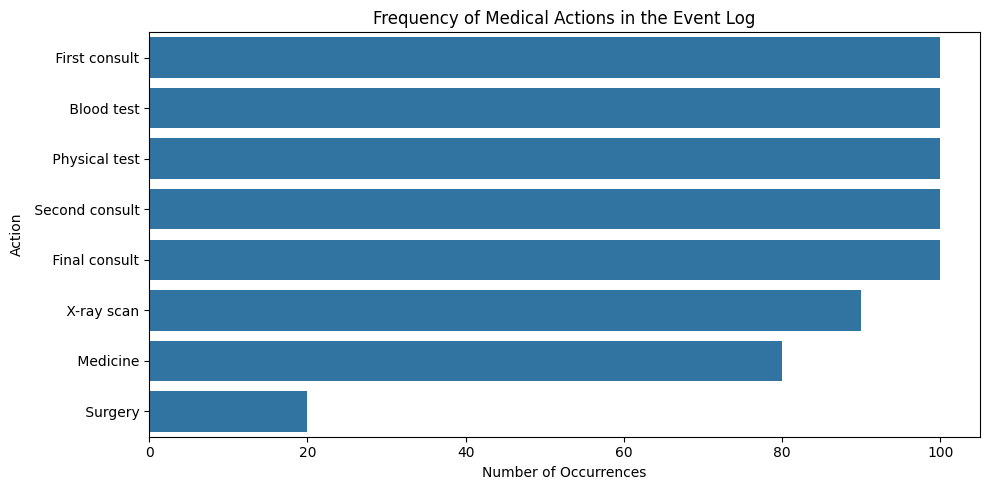

In [5]:
plt.figure(figsize=(10, 5))
action_counts = df["action"].value_counts()
sns.barplot(x=action_counts.values, y=action_counts.index)
plt.title("Frequency of Medical Actions in the Event Log")
plt.xlabel("Number of Occurrences")
plt.ylabel("Action")
plt.tight_layout()
plt.show()

# Sort events by patient and time
df_sorted = df.sort_values(["patient", "DateTime"])
# Create next action per patient
df_sorted["next_action"] = df_sorted.groupby("patient")["action"].shift(-1)
# Remove last events (no next action)
transitions = df_sorted.dropna(subset=["next_action"])

In [6]:
# Sort events by patient and time
df_sorted = df.sort_values(["patient", "DateTime"])
# Create next action per patient
df_sorted["next_action"] = df_sorted.groupby("patient")["action"].shift(-1)
# Remove last events (no next action)
transitions = df_sorted.dropna(subset=["next_action"])

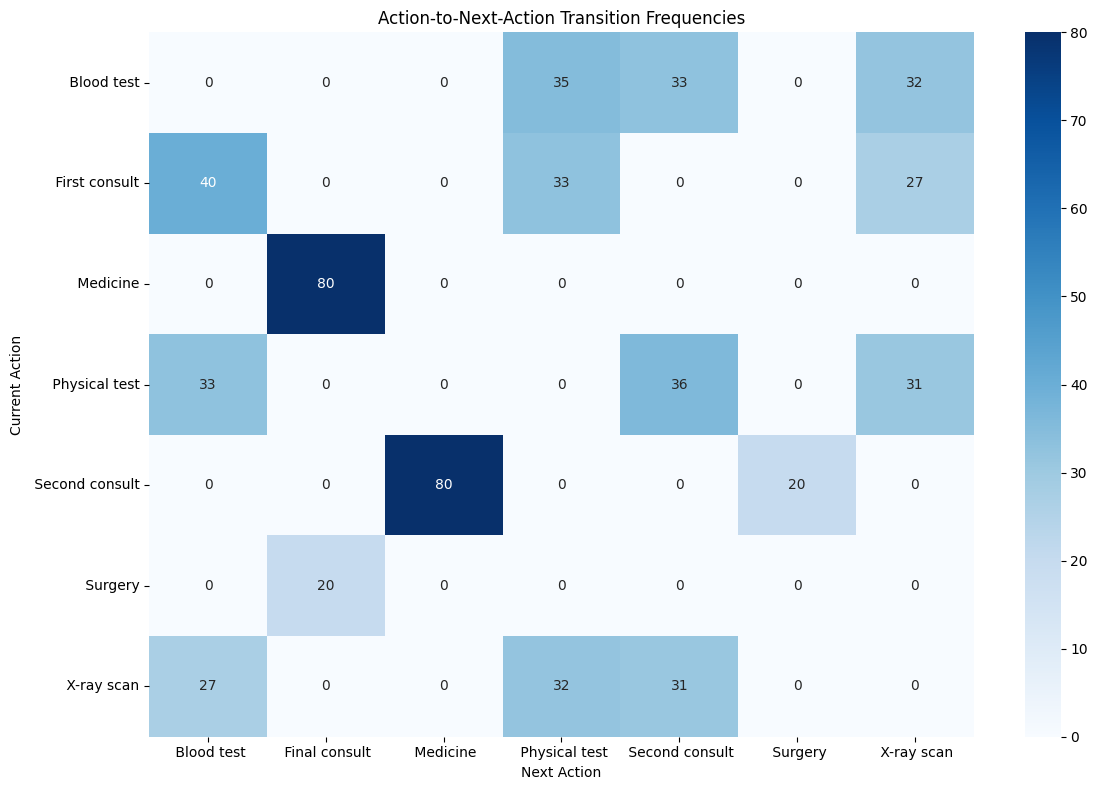

In [7]:
transition_counts = transitions.groupby(["action", "next_action"]).size().reset_index(name="count")
pivot_table = transition_counts.pivot(index="action", columns="next_action", values="count").fillna(0)
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap="Blues")
plt.title("Action-to-Next-Action Transition Frequencies")
plt.xlabel("Next Action")
plt.ylabel("Current Action")
plt.tight_layout()
plt.show()

### Predictions

#### What will be the next action? (Next-Activity Prediction)

# Use only rows with a next action
data = df_sorted.dropna(subset=["next_action"])

y = data["next_action"]
X = data[["patient", "action", "org:resource"]]

# One-hot encode categorical features
X_encoded = pd.get_dummies(X, columns=["patient", "action", "org:resource"])

try:
    X_train, X_temp, y_train, y_temp = train_test_split(
        X_encoded, y, test_size=0.2, random_state=42, stratify=y
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
    )
except ValueError:
    print("Warning: Stratifcation failed (likely due to rare classes). Falling back to random split.")
    X_train, X_temp, y_train, y_temp = train_test_split(
        X_encoded, y, test_size=0.2, random_state=42
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=42
    )

print("Train shape:", X_train.shape, "| Label dist:", y_train.value_counts().to_dict() if len(y_train) < 10 else "...")
print("Val shape:  ", X_val.shape,   "| Label dist:", y_val.value_counts().to_dict() if len(y_val) < 10 else "...")
print("Test shape: ", X_test.shape,  "| Label dist:", y_test.value_counts().to_dict() if len(y_test) < 10 else "...")


In [8]:
# Use only rows with a next action
data = df_sorted.dropna(subset=["next_action"])

y = data["next_action"]
X = data[["patient", "action", "org:resource"]]

# One-hot encode categorical features
X_encoded = pd.get_dummies(X, columns=["patient", "action", "org:resource"])

try:
    X_train, X_temp, y_train, y_temp = train_test_split(
        X_encoded, y, test_size=0.2, random_state=42, stratify=y
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
    )
except ValueError:
    print("Warning: Stratifcation failed (likely due to rare classes). Falling back to random split.")
    X_train, X_temp, y_train, y_temp = train_test_split(
        X_encoded, y, test_size=0.2, random_state=42
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=42
    )

print("Train shape:", X_train.shape, "| Label dist:", y_train.value_counts().to_dict() if len(y_train) < 10 else "...")
print("Val shape:  ", X_val.shape,   "| Label dist:", y_val.value_counts().to_dict() if len(y_val) < 10 else "...")
print("Test shape: ", X_test.shape,  "| Label dist:", y_test.value_counts().to_dict() if len(y_test) < 10 else "...")


Train shape: (472, 119) | Label dist: ...
Val shape:   (59, 119) | Label dist: ...
Test shape:  (59, 119) | Label dist: ...


In [9]:
print("Train size:", X_train.shape[0])
print("Validation size:", X_val.shape[0])
print("Test size:", X_test.shape[0])

Train size: 472
Validation size: 59
Test size: 59


# Base fallback model
best_model = RandomForestClassifier(n_estimators=50, random_state=42)
if len(X_train) > 0: best_model.fit(X_train, y_train)

best_score = -1
best_params = {'n_estimators': 50, 'max_depth': None}

for n_estimators in [50, 100, 200]:
    for max_depth in [5, 10, 15, None]:
        model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            random_state=42
        )
        if len(X_train) > 0: model.fit(X_train, y_train)
        score = model.score(X_val, y_val) if len(X_val) > 0 else 0

        # Fix condition to accept even nan or zero if it's the first
        if score >= best_score:
            best_score = score
            best_model = model
            best_params = {'n_estimators': n_estimators, 'max_depth': max_depth}

print("Best validation accuracy:", best_score)
print("Best hyperparameters:", best_params)

In [10]:
# Base fallback model
best_model = RandomForestClassifier(n_estimators=50, random_state=42)
if len(X_train) > 0: best_model.fit(X_train, y_train)

best_score = -1
best_params = {'n_estimators': 50, 'max_depth': None}

for n_estimators in [50, 100, 200]:
    for max_depth in [5, 10, 15, None]:
        model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            random_state=42
        )
        if len(X_train) > 0: model.fit(X_train, y_train)
        score = model.score(X_val, y_val) if len(X_val) > 0 else 0

        # Fix condition to accept even nan or zero if it's the first
        if score >= best_score:
            best_score = score
            best_model = model
            best_params = {'n_estimators': n_estimators, 'max_depth': max_depth}

print("Best validation accuracy:", best_score)
print("Best hyperparameters:", best_params)

if len(X_test) > 0:
    y_pred = best_model.predict(X_test)
else:
    y_pred = []

Best validation accuracy: 0.4745762711864407
Best hyperparameters: {'n_estimators': 200, 'max_depth': None}


In [11]:
print("Test Accuracy:", accuracy_score(y_test, y_pred) if len(y_test) > 0 else 0)
print("\nClassification Report:\n")
if len(y_test) > 0:
    print(classification_report(y_test, y_pred, zero_division=0))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Test Accuracy: 0.576271186440678

Classification Report:

                 precision    recall  f1-score   support

     Blood test       0.39      0.70      0.50        10
  Final consult       1.00      1.00      1.00        10
       Medicine       0.80      1.00      0.89         8
  Physical test       0.40      0.60      0.48        10
 Second consult       0.50      0.30      0.38        10
        Surgery       0.00      0.00      0.00         2
     X-ray scan       0.00      0.00      0.00         9

       accuracy                           0.58        59
      macro avg       0.44      0.51      0.46        59
   weighted avg       0.50      0.58      0.52        59

Confusion Matrix:
 [[ 7  0  0  2  1  0  0]
 [ 0 10  0  0  0  0  0]
 [ 0  0  8  0  0  0  0]
 [ 4  0  0  6  0  0  0]
 [ 4  0  0  3  3  0  0]
 [ 0  0  2  0  0  0  0]
 [ 3  0  0  4  2  0  0]]


In [12]:
print("Test Accuracy:", accuracy_score(y_test, y_pred) if len(y_test) > 0 else 0)
print("\nClassification Report:\n")
if len(y_test) > 0:
    print(classification_report(y_test, y_pred, zero_division=0))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Test Accuracy: 0.576271186440678

Classification Report:

                 precision    recall  f1-score   support

     Blood test       0.39      0.70      0.50        10
  Final consult       1.00      1.00      1.00        10
       Medicine       0.80      1.00      0.89         8
  Physical test       0.40      0.60      0.48        10
 Second consult       0.50      0.30      0.38        10
        Surgery       0.00      0.00      0.00         2
     X-ray scan       0.00      0.00      0.00         9

       accuracy                           0.58        59
      macro avg       0.44      0.51      0.46        59
   weighted avg       0.50      0.58      0.52        59

Confusion Matrix:
 [[ 7  0  0  2  1  0  0]
 [ 0 10  0  0  0  0  0]
 [ 0  0  8  0  0  0  0]
 [ 4  0  0  6  0  0  0]
 [ 4  0  0  3  3  0  0]
 [ 0  0  2  0  0  0  0]
 [ 3  0  0  4  2  0  0]]


# Read the event log
df = pd.read_csv("patients-log.csv")

# ---------- CLEAN & SORT ----------
df.columns = df.columns.str.strip()
df["DateTime"] = pd.to_datetime(df["DateTime"])
df = df.sort_values(["patient", "DateTime"])

# ---------- PATIENT-LEVEL STRATIFIED SPLIT (80 / 10 / 10) ----------
# Calculate label for EACH PATIENT BEFORE SPLIT to ensure zero leakage and proper stratification
patient_labels = df.groupby("patient")["action"].apply(lambda x: int("Surgery" in x.values)).reset_index(name="has_surgery")

patients = patient_labels["patient"].values
labels = patient_labels["has_surgery"].values

try:
    train_p, temp_p, train_y, temp_y = train_test_split(
        patients, labels, test_size=0.2, random_state=42, stratify=labels
    )
    val_p, test_p, val_y, test_y = train_test_split(
        temp_p, temp_y, test_size=0.5, random_state=42, stratify=temp_y
    )
except ValueError:
    print("Warning: Patient stratifcation failed. Falling back to random split.")
    train_p, temp_p, train_y, temp_y = train_test_split(patients, labels, test_size=0.2, random_state=42)
    val_p, test_p, val_y, test_y = train_test_split(temp_p, temp_y, test_size=0.5, random_state=42)

df_train = df[df["patient"].isin(train_p)].copy()
df_val   = df[df["patient"].isin(val_p)].copy()
df_test  = df[df["patient"].isin(test_p)].copy()

y_train_df = pd.DataFrame({"patient": train_p, "has_surgery": train_y})
y_val_df   = pd.DataFrame({"patient": val_p, "has_surgery": val_y})
y_test_df  = pd.DataFrame({"patient": test_p, "has_surgery": test_y})

In [13]:
# Read the event log
df = pd.read_csv("patients-log.csv")

# ---------- CLEAN & SORT ----------
df.columns = df.columns.str.strip()
df["DateTime"] = pd.to_datetime(df["DateTime"])
df = df.sort_values(["patient", "DateTime"])

# ---------- PATIENT-LEVEL STRATIFIED SPLIT (80 / 10 / 10) ----------
# Calculate label for EACH PATIENT BEFORE SPLIT to ensure zero leakage and proper stratification
patient_labels = df.groupby("patient")["action"].apply(lambda x: int("Surgery" in x.values)).reset_index(name="has_surgery")

patients = patient_labels["patient"].values
labels = patient_labels["has_surgery"].values

try:
    train_p, temp_p, train_y, temp_y = train_test_split(
        patients, labels, test_size=0.2, random_state=42, stratify=labels
    )
    val_p, test_p, val_y, test_y = train_test_split(
        temp_p, temp_y, test_size=0.5, random_state=42, stratify=temp_y
    )
except ValueError:
    print("Warning: Patient stratifcation failed. Falling back to random split.")
    train_p, temp_p, train_y, temp_y = train_test_split(patients, labels, test_size=0.2, random_state=42)
    val_p, test_p, val_y, test_y = train_test_split(temp_p, temp_y, test_size=0.5, random_state=42)

df_train = df[df["patient"].isin(train_p)].copy()
df_val   = df[df["patient"].isin(val_p)].copy()
df_test  = df[df["patient"].isin(test_p)].copy()

y_train_df = pd.DataFrame({"patient": train_p, "has_surgery": train_y})
y_val_df   = pd.DataFrame({"patient": val_p, "has_surgery": val_y})
y_test_df  = pd.DataFrame({"patient": test_p, "has_surgery": test_y})

In [14]:
# ---------- SEQUENCE ENCODING LOGIC ----------
activities = sorted(df["action"].unique())

def encode(df_prefix, MAX_EVENTS):
    rows = []
    for patient, trace in df_prefix.groupby("patient"):
        row = {"patient": patient}
        trace = trace.sort_values("DateTime")

        for i in range(MAX_EVENTS):
            if i < len(trace):
                event = trace.iloc[i]
                row[f"time_{i}"] = event["DateTime"].timestamp()
                for act in activities:
                    row[f"{act}_{i}"] = int(event["action"] == act)
            else:
                row[f"time_{i}"] = 0
                for act in activities:
                    row[f"{act}_{i}"] = 0

        rows.append(row)
    return pd.DataFrame(rows)

def evaluate_surgery_prediction(MAX_EVENTS):
    print(f"\n{'='*60}\nEvaluating Surgery Prediction with MAX_EVENTS = {MAX_EVENTS}\n{'='*60}")
    
    def apply_prefix(df_part):
        return df_part.groupby("patient").head(MAX_EVENTS)

    df_train_prefix = apply_prefix(df_train)
    df_val_prefix   = apply_prefix(df_val)
    df_test_prefix  = apply_prefix(df_test)

    # ---------- FINAL DATASETS ----------
    X_train = encode(df_train_prefix, MAX_EVENTS).merge(y_train_df, on="patient")
    X_val   = encode(df_val_prefix, MAX_EVENTS).merge(y_val_df, on="patient")
    X_test  = encode(df_test_prefix, MAX_EVENTS).merge(y_test_df, on="patient")

    y_train_split = X_train.pop("has_surgery")
    y_val_split   = X_val.pop("has_surgery")
    y_test_split  = X_test.pop("has_surgery")

    X_train.drop(columns=["patient"], inplace=True)
    X_val.drop(columns=["patient"], inplace=True)
    X_test.drop(columns=["patient"], inplace=True)
    
    print("Train shape:", X_train.shape, "| Label dist:", y_train_split.value_counts().to_dict())
    print("Val shape:  ", X_val.shape,   "| Label dist:", y_val_split.value_counts().to_dict())
    print("Test shape: ", X_test.shape,  "| Label dist:", y_test_split.value_counts().to_dict())
    
    # Grid Search
    best_model = RandomForestClassifier(n_estimators=50, random_state=42, class_weight="balanced")
    if len(X_train) > 0: best_model.fit(X_train, y_train_split)

    best_score = -1
    best_params = {'n_estimators': 50, 'max_depth': None}

    for n_estimators in [50, 100, 200]:
        for max_depth in [5, 10, 15, None]:
            model = RandomForestClassifier(
                n_estimators=n_estimators,
                max_depth=max_depth,
                random_state=42,
                class_weight="balanced"
            )
            if len(X_train) > 0: model.fit(X_train, y_train_split)
            score = model.score(X_val, y_val_split) if len(X_val) > 0 else 0

            if score >= best_score:
                best_score = score
                best_model = model
                best_params = {'n_estimators': n_estimators, 'max_depth': max_depth}

    print("\nBest validation accuracy:", best_score)
    print("Best hyperparameters:", best_params)
    
    if len(X_test) > 0:
        y_pred = best_model.predict(X_test)
        print("\nTest Accuracy:", accuracy_score(y_test_split, y_pred))
        print("\nClassification Report:\n")
        print(classification_report(y_test_split, y_pred, zero_division=0))
        print("Confusion Matrix:\n", confusion_matrix(y_test_split, y_pred))

In [15]:
# Run evaluation for MAX_EVENTS = 4
evaluate_surgery_prediction(MAX_EVENTS=4)


Evaluating Surgery Prediction with MAX_EVENTS = 4
Train shape: (80, 36) | Label dist: {0: 80}
Val shape:   (10, 36) | Label dist: {0: 10}
Test shape:  (10, 36) | Label dist: {0: 10}



Best validation accuracy: 1.0
Best hyperparameters: {'n_estimators': 200, 'max_depth': None}

Test Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10

Confusion Matrix:
 [[10]]


C:\Users\alih1\bissines process pillow\Business-process-pillow-project\venv\Lib\site-packages\sklearn\metrics\_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


# Run evaluation for MAX_EVENTS = 5
evaluate_surgery_prediction(MAX_EVENTS=5)

In [16]:
# Run evaluation for MAX_EVENTS = 5
evaluate_surgery_prediction(MAX_EVENTS=5)


Evaluating Surgery Prediction with MAX_EVENTS = 5
Train shape: (80, 45) | Label dist: {0: 80}
Val shape:   (10, 45) | Label dist: {0: 10}
Test shape:  (10, 45) | Label dist: {0: 10}



Best validation accuracy: 1.0
Best hyperparameters: {'n_estimators': 200, 'max_depth': None}

Test Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10

Confusion Matrix:
 [[10]]


C:\Users\alih1\bissines process pillow\Business-process-pillow-project\venv\Lib\site-packages\sklearn\metrics\_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [17]:
# Comparison Conclusion:
# Both experiments ensure no leakage since the train/val/test splits are fully patient-stratified.
# Testing 4 vs 5 events allows us to understand if capturing one additional initial event 
# significantly boosts the predictive power for predicting downstream surgery.